In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("D:\HR Analytics Project\data\processed\hr_cleaned.csv")
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)

feature_cols = ['Age','MonthlyIncome','YearsAtCompany','OverTime_enc',
                'JobSatisfaction','WorkLifeBalance','DistanceFromHome',
                'NumCompaniesWorked','TotalWorkingYears']

X = df[feature_cols]
y = (df['Attrition'] == 'Yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1]), 3))

              precision    recall  f1-score   support

           0       0.93      0.74      0.82       255
           1       0.26      0.62      0.37        39

    accuracy                           0.72       294
   macro avg       0.59      0.68      0.60       294
weighted avg       0.84      0.72      0.76       294

ROC-AUC: 0.708


              Feature  Coefficient
3        OverTime_enc     0.709099
7  NumCompaniesWorked     0.404135
2      YearsAtCompany     0.197346
6    DistanceFromHome     0.169827
5     WorkLifeBalance    -0.190882
0                 Age    -0.265555
1       MonthlyIncome    -0.286511
4     JobSatisfaction    -0.349562
8   TotalWorkingYears    -0.409966


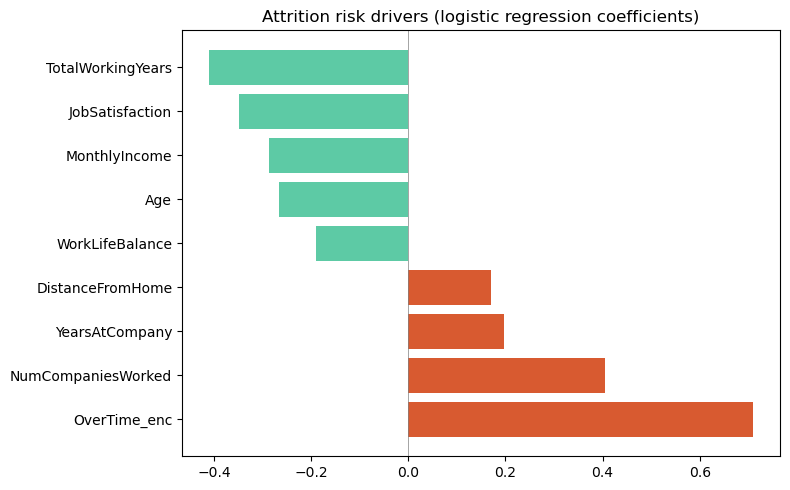

In [2]:
import numpy as np
import matplotlib.pyplot as plt

coefs = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coefs)

plt.figure(figsize=(8, 5))
plt.barh(coefs['Feature'], coefs['Coefficient'],
         color=['#D85A30' if c > 0 else '#5DCAA5' for c in coefs['Coefficient']])
plt.axvline(0, color='gray', linewidth=0.5)
plt.title('Attrition risk drivers (logistic regression coefficients)')
plt.tight_layout()
plt.savefig('../screenshots/risk_factors.png', dpi=150)

In [3]:
df_scored = df.copy()

X_all_sc = scaler.transform(df[feature_cols])

df_scored['AttritionProbability'] = model.predict_proba(X_all_sc)[:,1].round(3)

df_scored['RiskTier'] = pd.cut(
    df_scored['AttritionProbability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

df_scored['Attrition_bin'] = (df_scored['Attrition'] == 'Yes').astype(int)

print(df_scored.shape)
print(df_scored.columns.tolist())

df_scored.to_csv("D:\HR Analytics Project\data\processed\hr_scored.csv", index=False)
print("Saved successfully")

(1470, 41)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_enc', 'Department_enc', 'EducationField_enc', 'Gender_enc', 'JobRole_enc', 'MaritalStatus_enc', 'OverTime_enc', 'Attrition_bin', 'AttritionProbability', 'RiskTier']
Saved successfully
